In [2]:
import subprocess
import sys
def install_opencv_iran():
    mirrors = [
        "https://mirror-pypi.runflare.com/simple",
        "https://mirror2.chabokan.net/pypi/simple/",
        "https://pypi.jamko.ir/simple",
    ]
    
    for mirror in mirrors:
        try:
            print(f"Trying mirror: {mirror}")
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", 
                "--index-url", mirror, 
                "opencv-python", "opencv-contrib-python"
            ])
            print(f"✓ OpenCV installed successfully using {mirror}!")
            return True
        except:
            print(f"Failed with mirror {mirror}, trying next...")
    
    print("All installation methods failed. Please check your internet connection.")
    return False

if __name__ == "__main__":
    install_opencv_iran()

Attempting conda installation...
Conda method failed, trying pip with mirror...
Trying mirror: https://mirror-pypi.runflare.com/simple
✓ OpenCV installed successfully using https://mirror-pypi.runflare.com/simple!


In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np



First assignment of Image Processing homeworks
implementation of both parts of the assignment 

Reading input image... 
✓ The image has been read successfully

Trying to convert to HSV...
✓ Converted successfully

Trying to split H, S, and V in the HSV format image...
✓ Image saved as "hsv_analysis_output.png"


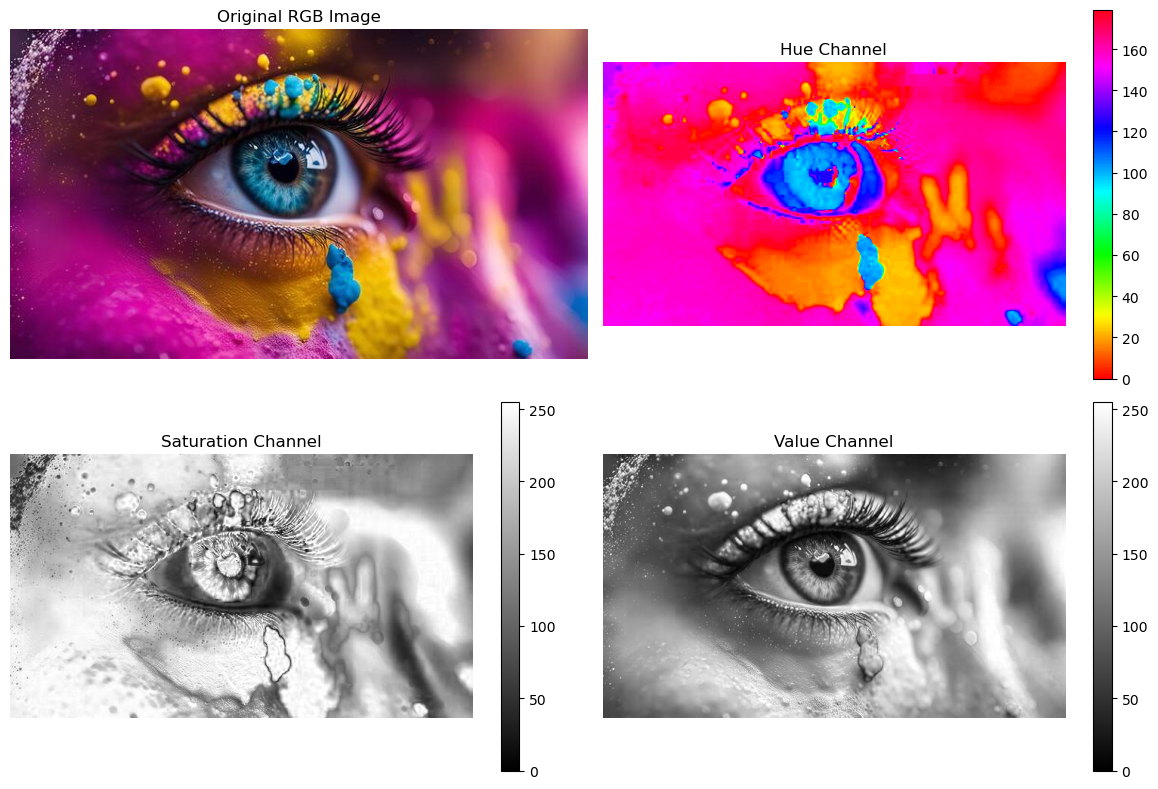

✓ Split successfully


In [11]:
import cv2 as cv
import matplotlib.pyplot as plt

# Part one
def convert_to_HSV(img):
    r_img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    return r_img

def HSV_Analysis(img):
    h, s, v = cv.split(img)
    
    # Create one figure with all channels
    plt.figure(figsize=(12, 8))
    
    # Original RGB
    original_rgb = cv.cvtColor(sample_img, cv.COLOR_BGR2RGB)
    plt.subplot(2, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Hue channel
    plt.subplot(2, 2, 2)
    plt.imshow(h, cmap='hsv')
    plt.title('Hue Channel')
    plt.colorbar()
    plt.axis('off')
    
    # Saturation channel
    plt.subplot(2, 2, 3)
    plt.imshow(s, cmap='gray')
    plt.title('Saturation Channel')
    plt.colorbar()
    plt.axis('off')
    
    # Value channel
    plt.subplot(2, 2, 4)
    plt.imshow(v, cmap='gray')
    plt.title('Value Channel')
    plt.colorbar()
    plt.axis('off')
    
    plt.tight_layout()
    
    # ✅ SAVE BEFORE SHOW
    plt.savefig('hsv_analysis_output.png', dpi=300, bbox_inches='tight')
    print('✓ Image saved as "hsv_analysis_output.png"')
    
    # Then show
    plt.show()

def convert_to_Grayscale():
    return

def Bit_Plane_Slicing():
    return

def main():
    print("First assignment of Image Processing homeworks")
    print("implementation of both parts of the assignment ")
    print('='*50)
    print('\nReading input image... ')
    
    global sample_img
    sample_img = cv.imread('.\Img_processing_one.jpg')
    
    if sample_img is None:
        print('✗ Error: Could not read the image. Check file path!')
        return
    else:
        print('✓ The image has been read successfully')
    
    print('\nTrying to convert to HSV...')
    try:
        HSV_img = convert_to_HSV(sample_img)
        print('✓ Converted successfully')
    except Exception as e:
        print(f"✗ Error in converting to HSV: {e}")
        return
    
    print('\nTrying to split H, S, and V in the HSV format image...')
    try:
        HSV_Analysis(HSV_img)
        print('✓ Split successfully')
    except Exception as e:
        print(f'✗ Error in splitting: {e}')

if __name__ == "__main__":
    main()

Welcome to part two of our first assignment!

1. Loading image and converting to grayscale...
   Image shape: (350, 613)
   Data type: uint8

2. Splitting into 8 bit-planes...
   Successfully extracted 8 bit-planes

3. Displaying bit-planes in 2x4 grid...
✓ Image saved as "hsv_analysis_output.png"


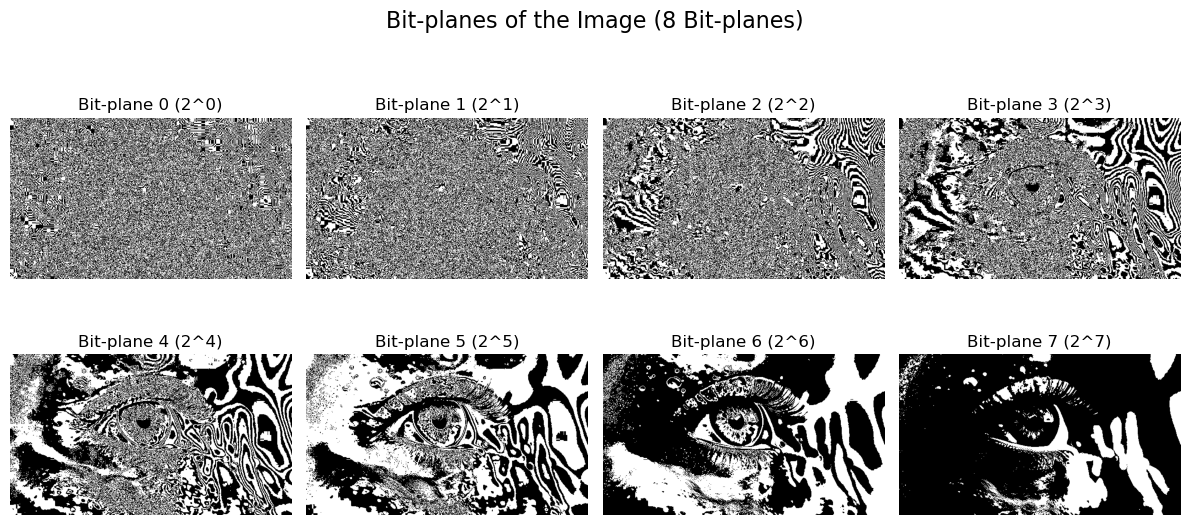

In [12]:
# Part two

def convert_to_grayscale(img):

    
    if len(img.shape) == 3:
        grayscale_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    else:
        grayscale_img = img
    return grayscale_img    

def split_bit_planes(img):
    
    bit_planes = []
    
    for i in range(8):  # 8 بیت برای هر پیکسل
        # استخراج بیت iام با استفاده از عملگر & (AND بیتی)
        bit_plane = (img >> i) & 1
        # برای نمایش بهتر، مقدار بیت را در ۲۵۵ ضرب می‌کنیم (سیاه و سفید)
        bit_plane_display = bit_plane * 255
        bit_planes.append(bit_plane_display.astype(np.uint8))
    
    return bit_planes

def display_bit_planes(bit_planes):
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle('Bit-planes of the Image (8 Bit-planes)', fontsize=16)
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(bit_planes[i], cmap='gray')
        ax.set_title(f'Bit-plane {i} (2^{i})')
        ax.axis('off')
    
    plt.tight_layout()

    # ✅ SAVE BEFORE SHOW
    plt.savefig('Bit-plane_analysis_output.png', dpi=300, bbox_inches='tight')
    print('✓ Image saved as "hsv_analysis_output.png"')
    
    plt.show()

def reconstruct_from_bit_planes(bit_planes, selected_bits):
    height, width = bit_planes[0].shape
    reconstructed = np.zeros((height, width), dtype=np.uint8)
    
    for bit_idx in selected_bits:
        # هر بیت را به جایگاه اصلی خود برگردانده و اضافه می‌کنیم
        reconstructed += (bit_planes[bit_idx] // 255) << bit_idx
    
    return reconstructed

def main():
    print("Welcome to part two of our first assignment!")
    print('='*50)
    
    # ۱. بارگذاری و تبدیل به خاکستری
    print('\n1. Loading image and converting to grayscale...')
    sample_img = cv.imread('Img_processing_one.jpg')
    
    if sample_img is None:
        print("Error: Could not read the image file. Please check the path.")
        return
    
    grayscale_img = convert_to_grayscale(sample_img)
    print(f"   Image shape: {grayscale_img.shape}")
    print(f"   Data type: {grayscale_img.dtype}")
    
    # ۲. تجزیه به ۸ صفحه بیتی
    print('\n2. Splitting into 8 bit-planes...')
    bit_planes = split_bit_planes(grayscale_img)
    print("   Successfully extracted 8 bit-planes")
    
    # ۳. نمایش صفحات بیتی در چیدمان ۲ در ۴
    print('\n3. Displaying bit-planes in 2x4 grid...')
    display_bit_planes(bit_planes)
main()